In [1]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
from physion.utils import plot_tools as pt

# disable UserWarning from pynwb
#import warnings
#warnings.filterwarnings("ignore")

"skimage" module not found


In [64]:
def compute_high_arousal_cond(behav_episodes,
                              pupil_threshold,
                              running_speed_threshold):
    # HAcond: high arousal condition
    if pupil_threshold is not None:
        HAcond = (behav_episodes.pupil_diameter.mean(axis=1)>pupil_threshold)
    else:
        print("hey", behav_episodes)
        print("hey", behav_episodes.running_speed)
        print("hey", behav_episodes.running_speed.mean(axis=1))
        
        HAcond = (behav_episodes.running_speed.mean(axis=1)>running_speed_threshold) 
        
    return HAcond
    
def compute_high_movement_cond(behav_episodes,
                               running_speed_threshold):
    # HMcond: high movement condition
    if running_speed_threshold is not None:
        HMcond = (behav_episodes.running_speed.mean(axis=1)>running_speed_threshold) 
    #print(len(behav_episodes))
    print(len(HMcond))
    return HMcond

    
def plot_behavior_in_episodes(data,
                              ax=None,
                              running_speed_threshold=0.1,
                              pupil_threshold=None):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    if ax is None:
        fig, ax = plt.subplots(1, figsize=(2,1.3))
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
    else:
        fig = None

    HAcount, LAcount = [], []
    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HAcond: high arousal condition
        HAcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold)
        print(HAcond)
            
        ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[~HAcond],
                behav_episodes.running_speed.mean(axis=1)[~HAcond], 'o', color='tab:blue')
        ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[HAcond],
                behav_episodes.running_speed.mean(axis=1)[HAcond], 'o', color='tab:orange')
        
        HAcount.append(np.sum(HAcond))
        LAcount.append(np.sum(~HAcond))
        
    ax.set_ylabel('run. speed (cm/s)')
    ax.set_xlabel('pupil size (mm)')
    ax.annotate('\n n=%i ep.' % np.sum(HAcount), (0, 1), color='tab:orange', xycoords='axes fraction', va='top')
    ax.annotate(' n=%i ep.' % np.sum(LAcount), (0, 1), color='tab:blue', xycoords='axes fraction', va='top')
    
    return fig, ax



In [3]:
def plot_average_visually_evoked_activity2(data,
                                          roiIndex=None,
                                          running_speed_threshold=0.1):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    # prepare array for final results (averaged over sessions)
    RESULTS = {}
    for protocol in protocols:
        RESULTS[protocol] = {'significant':[], 'response':[], 'session':[]}


    fig, AX = plt.subplots(5, len(protocols),
                              figsize=(7,5))
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HMcond: high movement condition
        HMcond = compute_high_movement_cond(behav_episodes, running_speed_threshold)
        
        episodes = EpisodeData(data,
                               quantities=['dFoF'],
                               protocol_name=protocol,
                               verbose=False)
        varied_keys = [k for k in episodes.varied_parameters.keys() if k!='repeat']
        varied_values = [episodes.varied_parameters[k] for k in varied_keys]

        AX[0][p].annotate(protocol.replace('Natural-Images-4-repeats','natural-images'),
                          (0.5,1.4),
                          xycoords='axes fraction', ha='center')

        i=0
        for values in itertools.product(*varied_values):

            stim_cond = episodes.find_episode_cond(key=varied_keys, value=values)

            #inset
            inset = pt.inset(AX[i][p], [0.55, 0.9, 0.3, 0.2])
            rest = sum(stim_cond & (~HMcond))
            run  = sum(stim_cond & HMcond)
            inset.pie([rest, run], 
                       autopct='%1.1f%%', 
                       colors = ['tab:blue', 'tab:orange'], 
                       textprops={'fontsize': 5}, 
                       #labeldistance=0.5)  # Move labels outside
                       pctdistance=2  )  # Move percentage text closer to the edge

            #rest trace
            if np.sum(~HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & (~HMcond),
                                   with_std=False, with_stim=False,
                                   color='tab:blue',
                                   AX=[[AX[i][p]]], no_set=True)
            #running trace
            if np.sum(HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & HMcond,
                                   with_std=False, with_stim=True,
                                   color='tab:orange',
                                   AX=[[AX[i][p]]], no_set=True)

            RESULTS[protocol]['significant'].append([])
            RESULTS[protocol]['response'].append([])
            RESULTS[protocol]['session'].append([])
            i+=1

    if roiIndex is None:
        AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[-1][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 0), xycoords='axes fraction')

    pt.set_common_ylims(AX)
    for ax in pt.flatten(AX):
        ax.axis('off')
        if np.isfinite(ax.dataLim.x0) and ax==AX[0][0]:
            pt.draw_bar_scales(ax,
                               Xbar=1., Xbar_label='1s',
                               Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
    pt.set_common_xlims(AX)
    
    return fig

<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:92: SyntaxWarning: invalid escape sequence '\D'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_5492\2213335224.py:78: SyntaxWarning: invalid escape sequence '\p'
  AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_5492\2213335224.py:92: SyntaxWarning: invalid escape sequence '\D'
  Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)


In [11]:
def plot_average_visually_evoked_activity3(data,
                                          roiIndex=None,
                                          running_speed_threshold=0.1):
    
    protocol = data.protocols
    RESULTS = {'significant':[], 'response':[], 'session':[]}

    fig, AX = plt.subplots(1, 1, figsize=(2, 1.3), squeeze=False)
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)
    AX[0][0].annotate(protocol[0].replace('ff-gratings-8orientation-2contrasts-15repeats', '8ori-2contrasts'),
                     (0.5,1.4),
                      xycoords='axes fraction', 
                      ha='center')

    behav_episodes = EpisodeData(data, 
                                 quantities=['Pupil', 'Running-Speed'],
                                 protocol_name=protocol,
                                 prestim_duration=0,
                                 verbose=False)
        
    # HMcond: high movement condition
    HMcond = compute_high_movement_cond(behav_episodes, running_speed_threshold)
    #HMcond = np.append(HMcond, False)  #weird
   
    episodes = EpisodeData(data,
                           quantities=['dFoF'],
                           protocol_name=protocol,
                           verbose=False)
    
    #rest trace
    plot_trial_average(episodes, 
                       roiIndex=roiIndex,
                       condition=(~HMcond),
                       with_std=False, with_stim=False,
                       color='tab:blue',
                       AX=[[AX[0][0]]], 
                       no_set=True)
       
    #running trace
    plot_trial_average(episodes, 
                    roiIndex=roiIndex,
                    condition=(HMcond),
                    with_std=False, with_stim=True,
                    color='tab:orange',
                    AX=[[AX[0][0]]], 
                    no_set=True)
    
    #inset
    inset = pt.inset(AX[0][0], [0.55, 0.9, 0.3, 0.2])
    rest = sum(~HMcond)
    run  = sum(HMcond)
    inset.pie([rest, run], 
               autopct='%1.1f%%', 
               colors = ['tab:blue', 'tab:orange'], 
               textprops={'fontsize': 5}, 
               pctdistance=2  )  # Move percentage text closer to the edge
    
    RESULTS['significant'].append([])
    RESULTS['response'].append([])
    RESULTS['session'].append([])
        

    if roiIndex is None:
        AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[0][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 1.2), xycoords='axes fraction')

    return fig

<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_5492\835530997.py:64: SyntaxWarning: invalid escape sequence '\p'
  AX[0][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\


# NDNF 2022

In [22]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]
#SESSIONS[['nwbfiles', 'subjects', 'dates', 'protocols']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 12.8s) 


In [23]:
index = 2
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

Text(1, 1, ' low arousal')

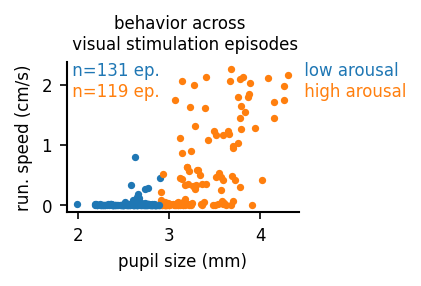

In [24]:
fig, ax = plot_behavior_in_episodes(data, pupil_threshold=2.9)
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='tab:orange', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='tab:blue', xycoords='axes fraction', va='top')

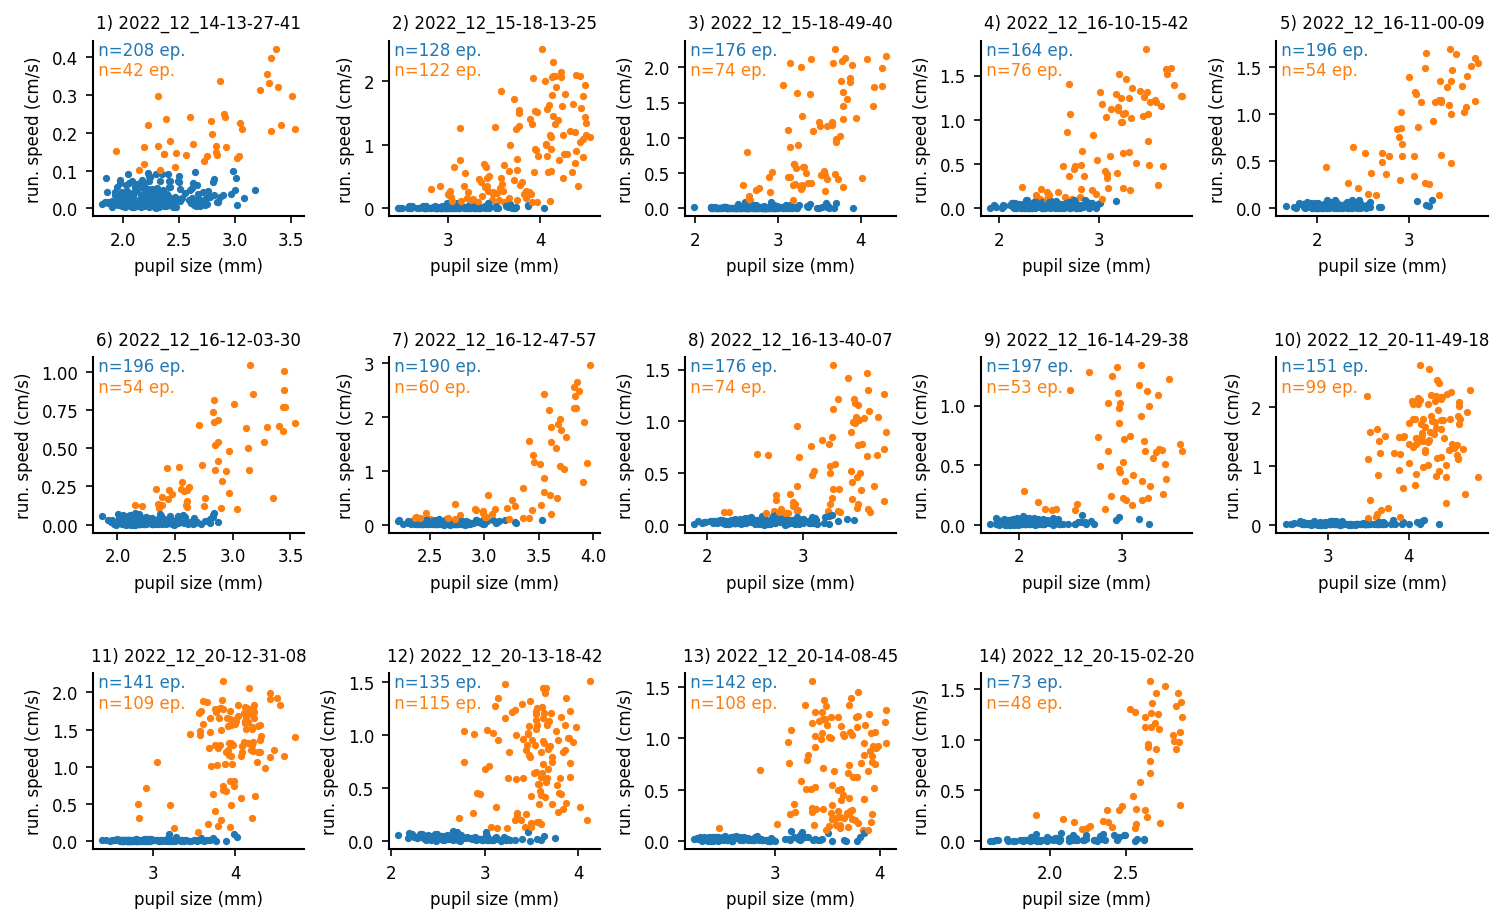

In [25]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5])
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    

for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

In [9]:
protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol
print(protocols)
STAT_TEST = {}
for protocol in protocols:
    # a default stat test
    STAT_TEST[protocol] = dict(interval_pre=[-1,0],
                               interval_post=[1,2],
                               test='ttest',
                               positive=True)
    
STAT_TEST['looming-stim']['interval_post'] = [2, 3]
STAT_TEST['drifting-gratings']['interval_post'] = [1.5, 2.5]
STAT_TEST['moving-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['random-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['static-patch']['interval_post'] = [0.5, 1.5]


[np.str_('moving-dots'), np.str_('random-dots'), np.str_('static-patch'), np.str_('looming-stim'), np.str_('Natural-Images-4-repeats'), np.str_('drifting-gratings')]


40
40 40 40 40
[False False False  True False False  True  True  True False False False
 False  True False  True  True False  True  True  True  True False False
 False False  True  True  True False  True False False  True  True  True
 False False  True  True]
40 40 40 40
[ True  True  True False  True  True False False False  True  True  True
  True False  True False False  True False False False False  True  True
  True  True False False False  True False  True  True False False False
  True  True False False]
40
40 40 40 40
[ True  True False False False False False  True False False False False
 False  True  True False False False False False False False False False
 False False False  True False False False False False  True False  True
 False False False  True]
40 40 40 40
[False False  True  True False False False False False False False False
 False False False False  True False False  True  True False False  True
  True False False False False False False False False False  Tru

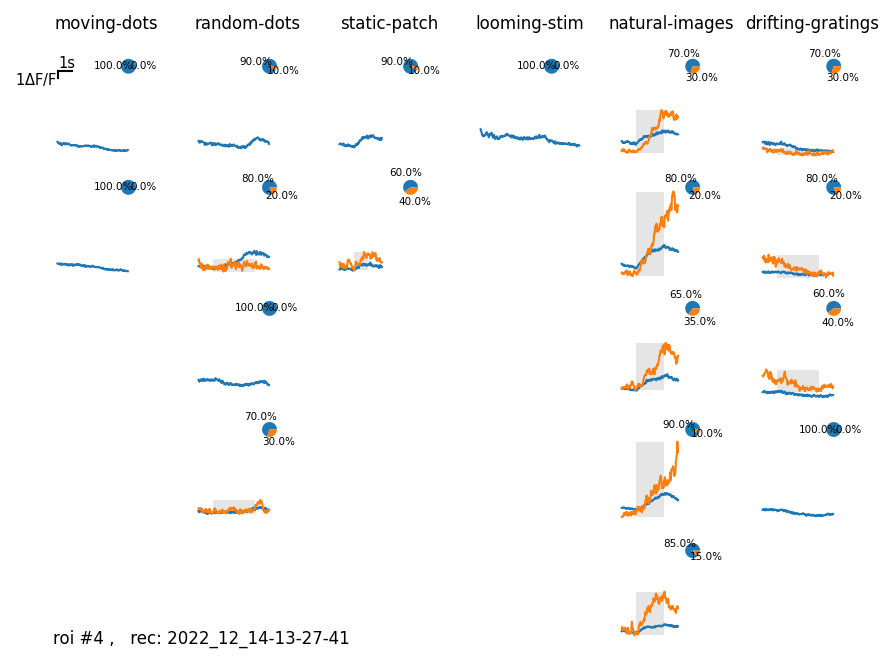

In [10]:
dataIndex, roiIndex = 0, 3
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex, running_speed_threshold=0.1)

40
40 40 40 40
[False False False False False False  True  True  True False False False
 False  True False  True  True False  True  True  True  True False False
 False False False  True  True False  True False False  True False  True
 False False  True  True]
40 40 40 40
[False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False False  True False
 False False False False]
40 40 40 40
[ True  True  True False False  True False False False  True  True  True
  True False  True False False  True False False False False  True False
 False  True False False False  True False  True  True False False False
  True  True False False]
40 40 40 40
[False False False False  True False False False False False False False
 False False False False False False False False False False False  True
  True False False False False False False False False False False F

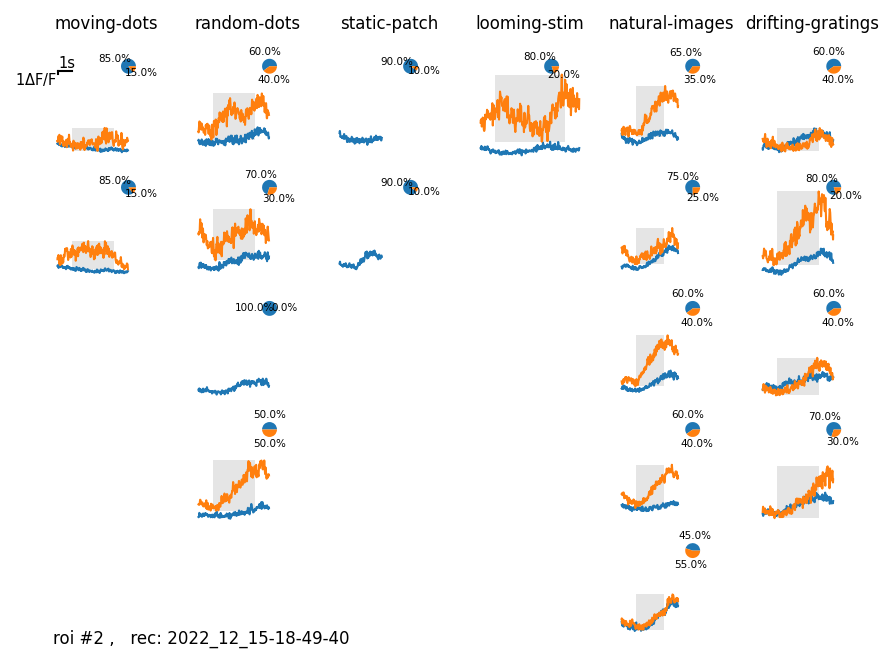

In [11]:
dataIndex, roiIndex = 2, 1
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

40
40 40 40 40
[False False False False False False  True  True  True False False False
 False  True False  True  True False  True  True  True  True False False
 False False False  True  True False  True False False  True False  True
 False False  True  True]
40 40 40 40
[False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False False  True False
 False False False False]
40 40 40 40
[ True  True  True False False  True False False False  True  True  True
  True False  True False False  True False False False False  True False
 False  True False False False  True False  True  True False False False
  True  True False False]
40 40 40 40
[False False False False  True False False False False False False False
 False False False False False False False False False False False  True
  True False False False False False False False False False False F

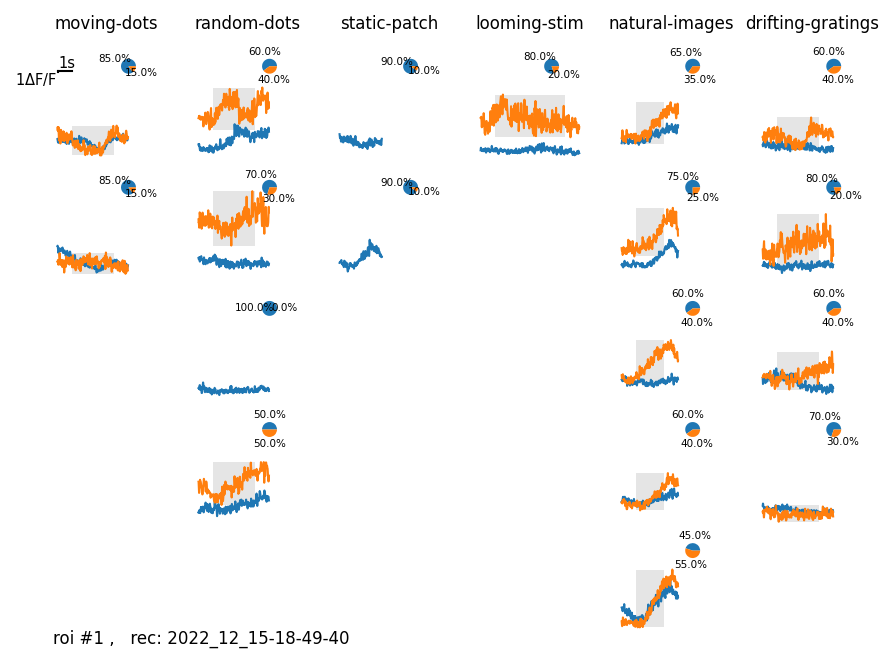

In [12]:
dataIndex, roiIndex = 2, 0
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

40
40 40 40 40
[False False False False False False  True  True  True False False False
 False  True False  True  True False  True  True  True  True False False
 False False False  True  True False  True False False  True False  True
 False False  True  True]
40 40 40 40
[False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False False  True False
 False False False False]
40 40 40 40
[ True  True  True False False  True False False False  True  True  True
  True False  True False False  True False False False False  True False
 False  True False False False  True False  True  True False False False
  True  True False False]
40 40 40 40
[False False False False  True False False False False False False False
 False False False False False False False False False False False  True
  True False False False False False False False False False False F

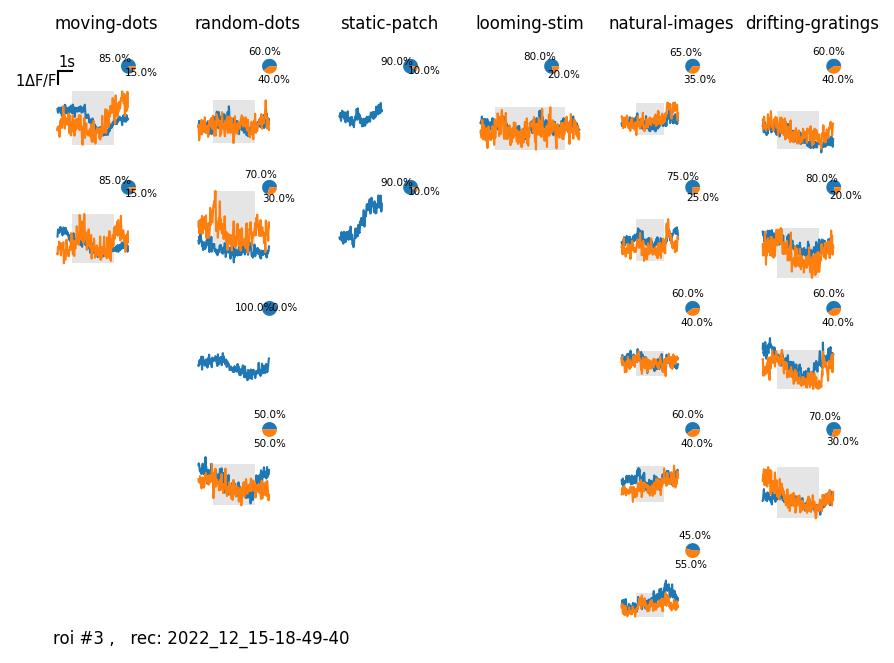

In [13]:
dataIndex, roiIndex = 2, 2
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

40
40 40 40 40
[False False False False False False  True  True  True False False False
 False  True False  True  True False  True  True  True  True False False
 False False False  True  True False  True False False  True False  True
 False False  True  True]
40 40 40 40
[False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False False  True False
 False False False False]
40 40 40 40
[ True  True  True False False  True False False False  True  True  True
  True False  True False False  True False False False False  True False
 False  True False False False  True False  True  True False False False
  True  True False False]
40 40 40 40
[False False False False  True False False False False False False False
 False False False False False False False False False False False  True
  True False False False False False False False False False False F

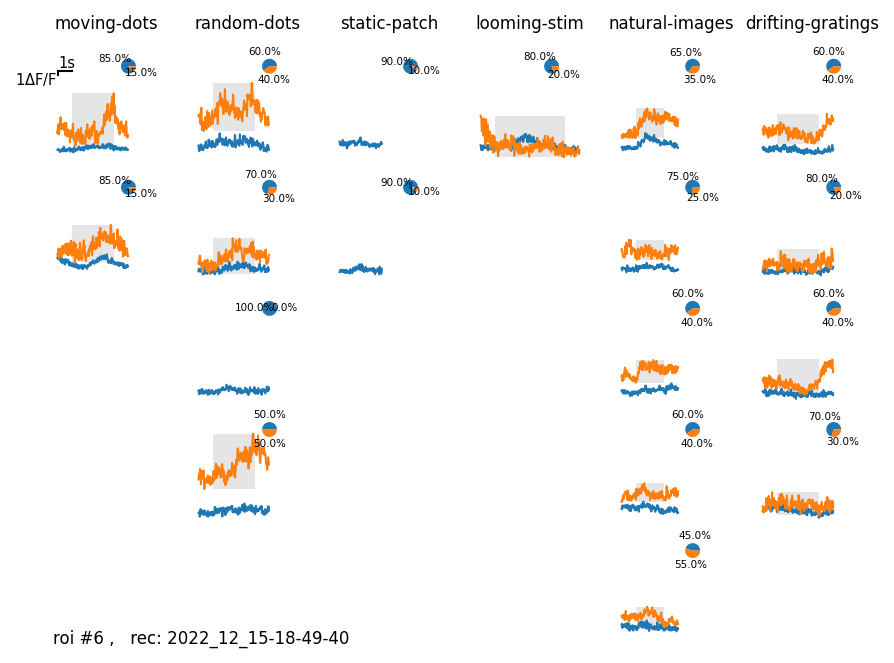

In [14]:
dataIndex, roiIndex = 2, 5
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

40
40 40 40 40
[False False False False False False  True  True  True False False False
 False  True False  True  True False  True  True  True  True False False
 False False False  True  True False  True False False  True False  True
 False False  True  True]
40 40 40 40
[False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False False  True False
 False False False False]
40 40 40 40
[ True  True  True False False  True False False False  True  True  True
  True False  True False False  True False False False False  True False
 False  True False False False  True False  True  True False False False
  True  True False False]
40 40 40 40
[False False False False  True False False False False False False False
 False False False False False False False False False False False  True
  True False False False False False False False False False False F

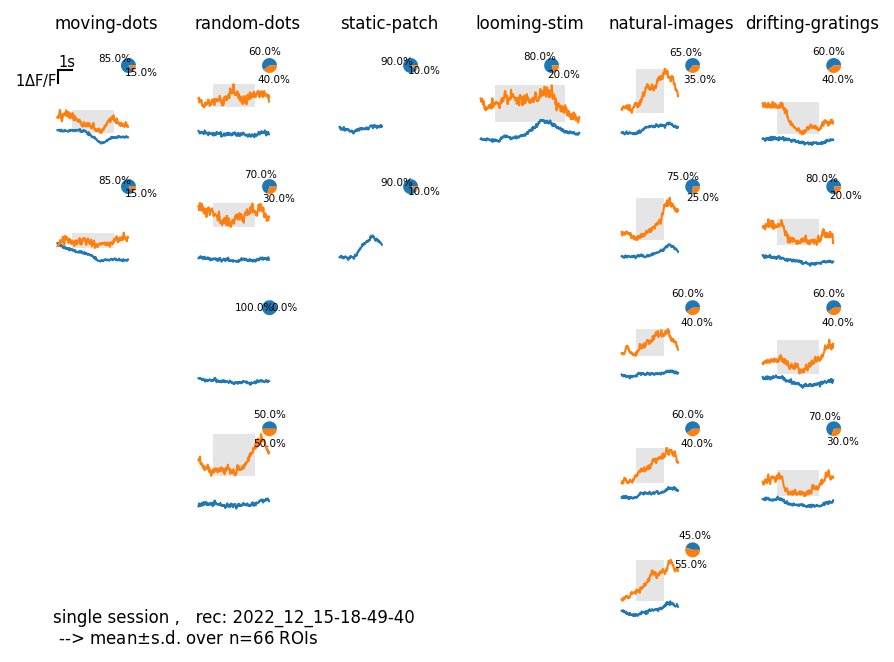

In [15]:
dataIndex, roiIndex = 2, None
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

40
40 40 40 40
[False False False  True False False False  True  True False False False
 False False False  True  True False  True  True  True  True False False
 False False False  True  True False  True False False  True  True  True
 False False  True False]
40 40 40 40
[False False False False False False  True False False False False False
 False  True False False False False False False False False False False
 False False  True False False False False False False False False False
 False False False  True]
40 40 40 40
[ True  True  True False  True  True False False False False  True False
 False False  True False False False False False False False False False
  True  True False False False  True False  True  True False False False
 False  True False False]
40 40 40 40
[False False False False False False False False False  True False  True
  True False False False False  True False False False False  True  True
 False False False False False False False False False False False F

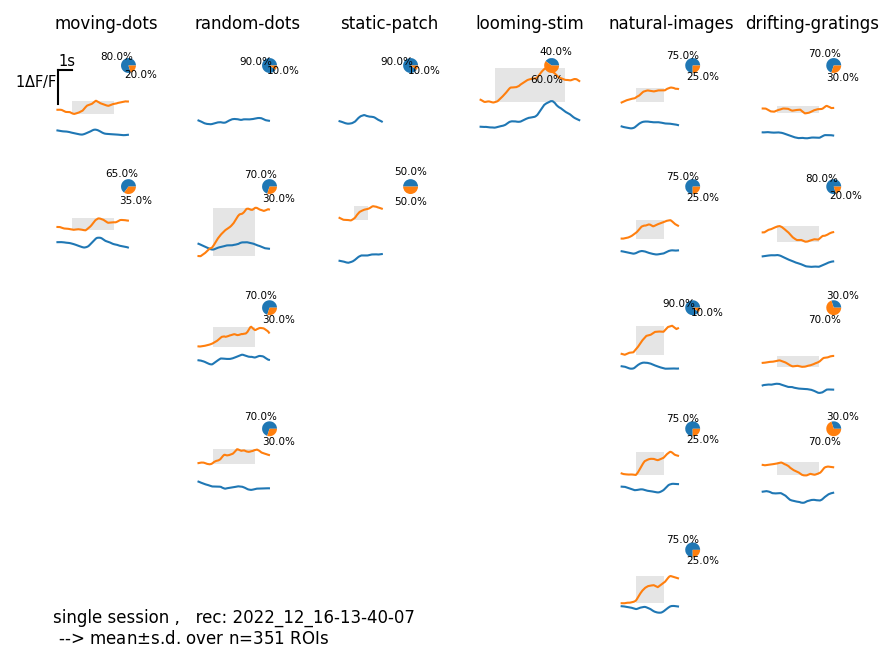

In [16]:
dataIndex, roiIndex = 7, None
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

# SST Keta vs Saline Cibele and Sofia 2024-2025

In [36]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\All_NWBs" [...]
 -> found n=20 datafiles (in 12.5s) 


In [37]:
index = 8
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

print(data.protocols)

['injection-monitoring']


Text(1, 1, ' low arousal')

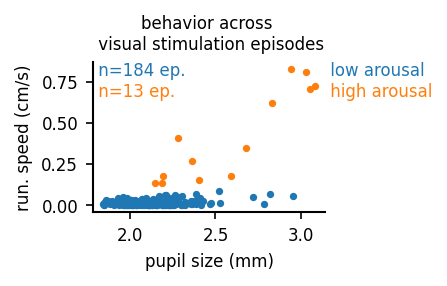

In [38]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1)
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='tab:orange', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='tab:blue', xycoords='axes fraction', va='top')

'Data' object has no attribute 'pupil_diameter'
'Data' object has no attribute 'pupil_diameter'
'Data' object has no attribute 'pupil_diameter'


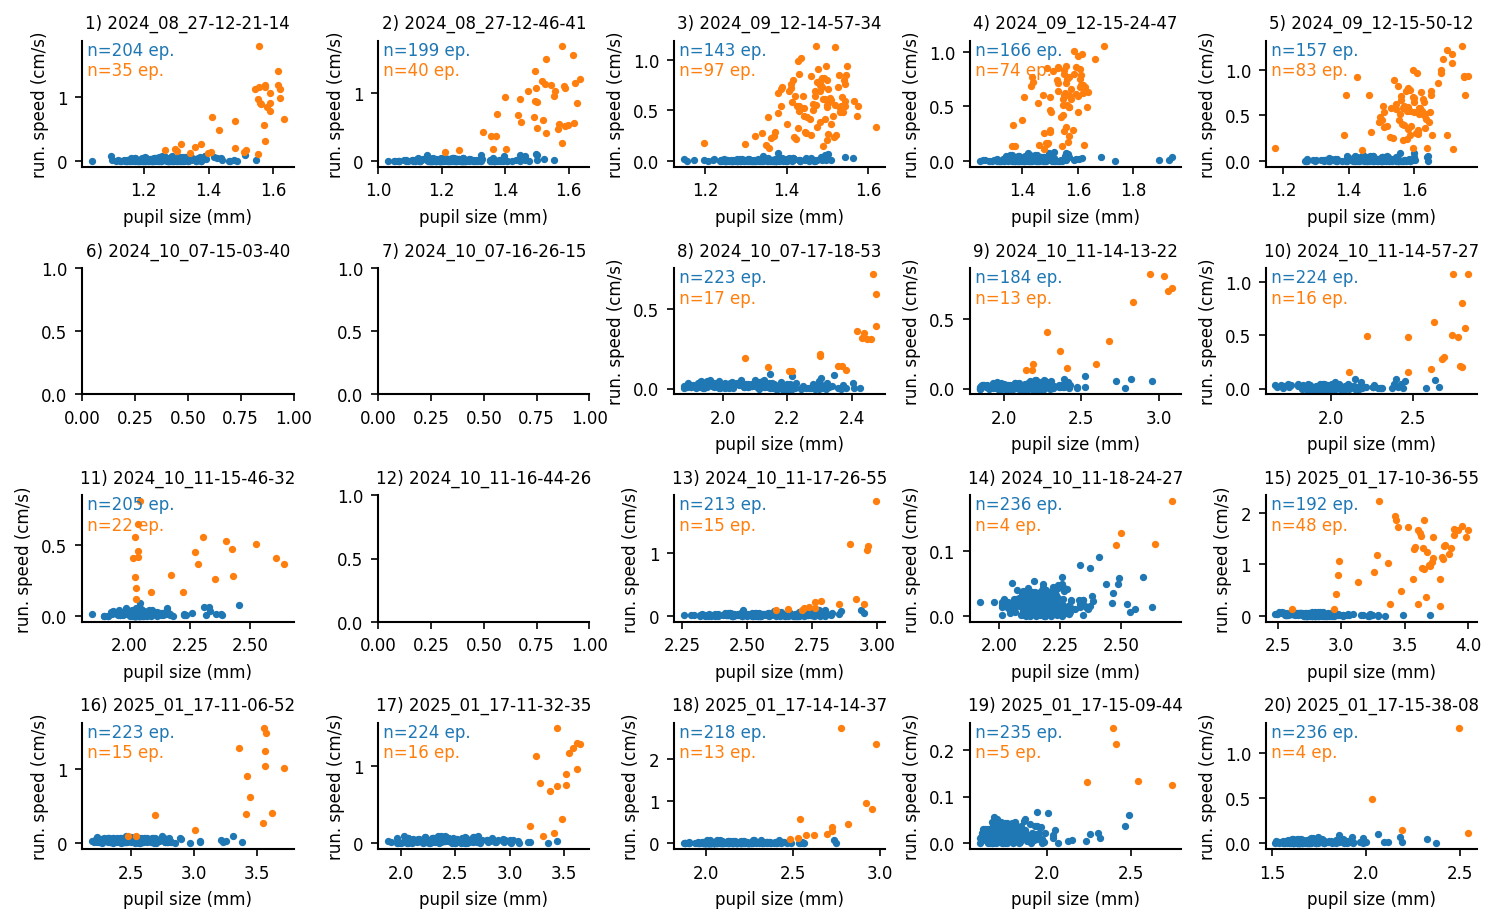

In [39]:
rows = 4
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    try:
        data = Data(filename, verbose=False)
        plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5])
    except Exception as e:
        print(e)
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)


for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

197


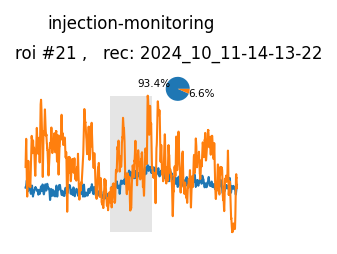

In [40]:
dataIndex, roiIndex = 8, 20
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
fig = plot_average_visually_evoked_activity3(data, roiIndex=roiIndex, running_speed_threshold=0.1)

240


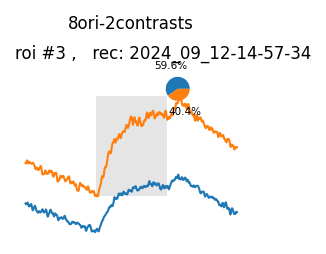

240


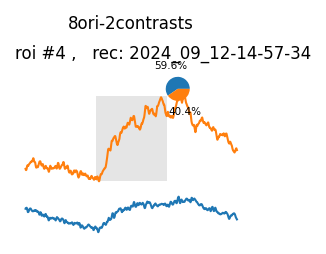

240


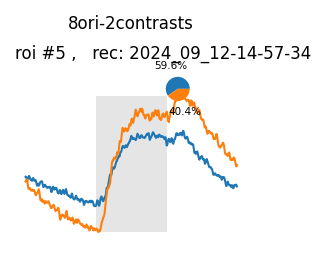

240


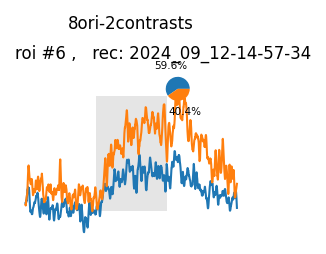

240


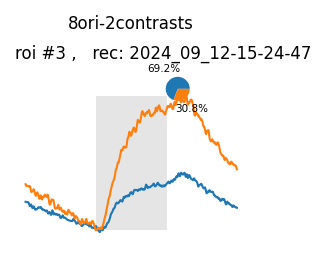

240


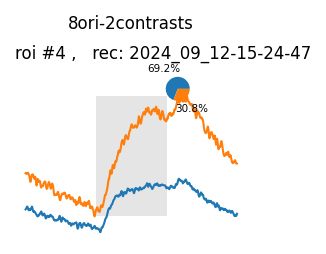

240


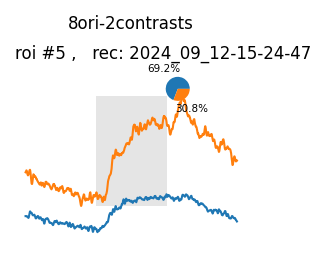

240


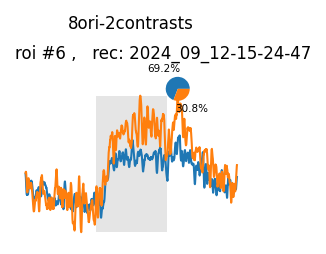

240


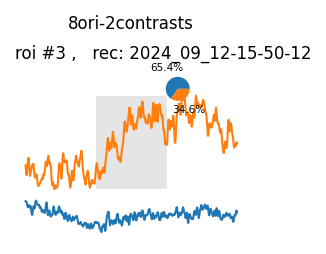

240


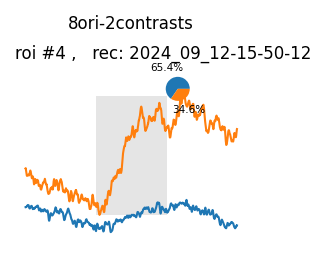

240


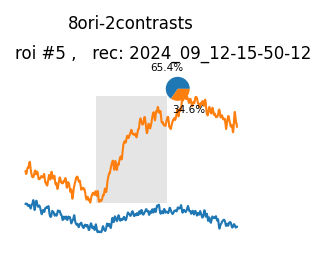

240


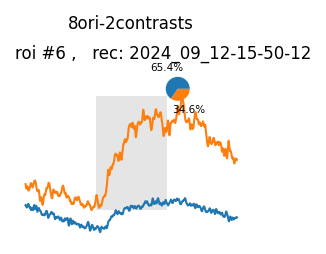

AttributeError: 'Data' object has no attribute 'pupil_diameter'

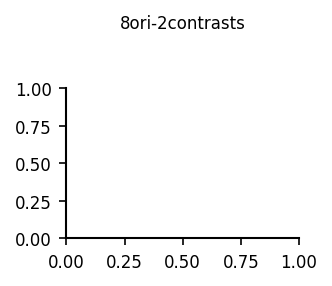

In [41]:
for i in range(2,10):
    for j in range(2,6):
        dataIndex, roiIndex = i, j
        data = Data(SESSIONS['files'][dataIndex], verbose=False)
        data.build_dFoF(verbose=False)
        fig = plot_average_visually_evoked_activity3(data, roiIndex=roiIndex, running_speed_threshold=0.1)
        plt.show()

# SST Keta vs Saline Taddy Yann 2023

not enough data!!!

In [44]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments', 'SST-Ketamine-vs-Saline', 'All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\SST-Ketamine-vs-Saline\All_NWBs" [...]


C:\Users\laura.gonzalez\AppData\Local\miniforge3\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


 -> found n=5 datafiles (in 3.0s) 


In [67]:
index = 3
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

C:\Users\laura.gonzalez\AppData\Local\miniforge3\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


hey <physion.analysis.process_NWB.EpisodeData object at 0x000002AD177B6930>
hey [[0.32128171 0.32293731 0.32459291 ... 0.17503401 0.17411136 0.17318871]
 [0.13489341 0.13334994 0.13180648 ... 0.23663637 0.23656196 0.23648755]
 [2.20134375 2.19227485 2.18320595 ... 1.02916072 1.03420959 1.03925845]
 [0.10229726 0.10272523 0.10315319 ... 0.35472486 0.35216632 0.34960777]]
hey [0.20574736 0.14171475 0.99467979 0.14864528]
[ True  True  True  True]


Text(1, 1, ' low arousal')

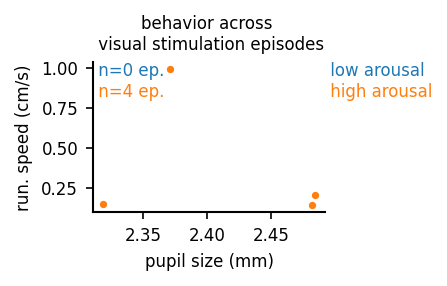

In [68]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1)
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='tab:orange', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='tab:blue', xycoords='axes fraction', va='top')

In [73]:
index = 0
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

hey <physion.analysis.process_NWB.EpisodeData object at 0x000002AD5EA4F6E0>
hey [[0. 0. 0. ... 0. 0. 0.]]
hey [0.02012619]
[False]


Text(1, 1, ' low arousal')

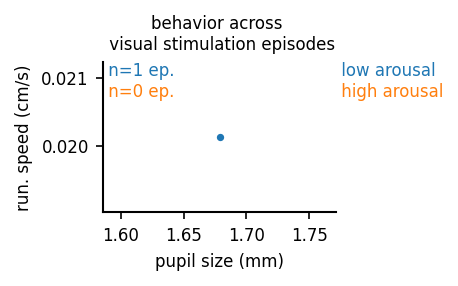

In [74]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1)
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='tab:orange', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='tab:blue', xycoords='axes fraction', va='top')